<a href="https://colab.research.google.com/github/crahulnaidu/recursive-self-improving-ai/blob/main/month_1/ai_month_1_day_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
#Comparing the convergence speed using GD,momentum and ADAM

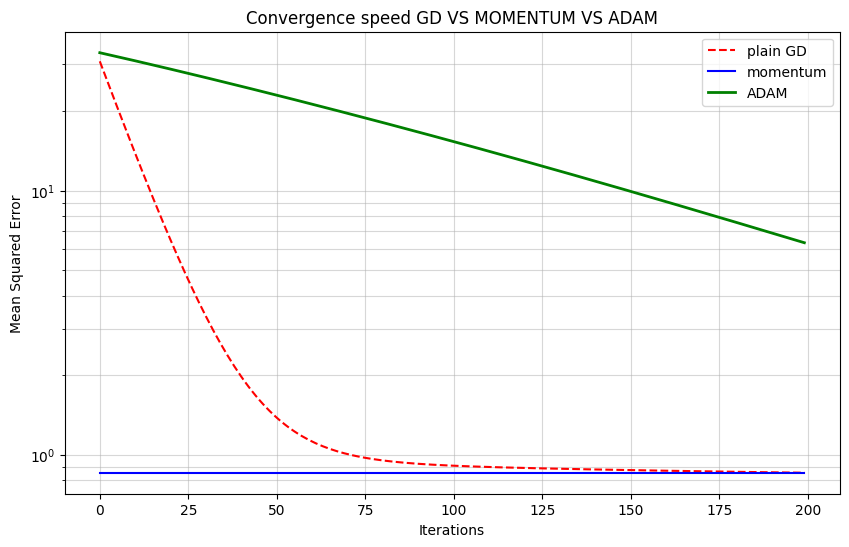

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
X=2*np.random.rand(100,1)
y=4+3*X+np.random.randn(100,1)

lr=0.01
iterations=200
theta_init=np.random.rand(2,1)

def get_gradient(theta,X_b,y):
  m=len(y)
  return 2/m*X_b.T.dot(X_b.dot(theta)-y)

X_b=np.c_[np.ones((100,1)),X]

#plain gradient descent

theta_gd=theta_init.copy()
loss_gd=[]

for _ in range(iterations):
  gradient=get_gradient(theta_gd,X_b,y)
  theta_gd=theta_gd-lr*gradient
  loss_gd.append(np.mean((X_b.dot(theta_gd)-y)**2))

#momentum optimizer

theta_mom=theta_init.copy()
loss_mom=[]
v=np.zeros_like(theta_init)
beta=0.9 #momentum coefficient

for _ in range(iterations):
  grad=get_gradient(theta_mom,X_b,y)
  v=beta*v+lr*grad
  theta_mom=theta_mom-v
  loss_mom.append(np.mean((X_b.dot(theta_gd)-y)**2))


#Adam optimizer

theta_adam=theta_init.copy()
loss_adam=[]
m_t,v_t=np.zeros_like(theta_init),np.zeros_like(theta_init)
beta1,beta2=0.9,0.999
eps=1e-8

for t in range(1,iterations+1):
  grad=get_gradient(theta_adam,X_b,y)
  m_t=beta1*m_t+(1-beta1)*grad
  v_t=beta2*v_t+(1-beta2)*(grad**2)

  #bias correction

  m_hat=m_t/(1-beta1**t)
  v_hat=v_t/(1-beta2**t)


  theta_adam=theta_adam-lr*m_hat/(np.sqrt(v_hat)+eps)
  loss_adam.append(np.mean((X_b.dot(theta_adam)-y)**2))


#plotting the results

plt.figure(figsize=(10,6))
plt.plot(loss_gd,label="plain GD",color='red',linestyle='--')
plt.plot(loss_mom,label="momentum",color='blue')
plt.plot(loss_adam,label="ADAM",color='green',linewidth=2)
plt.yscale('log')
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error")
plt.title("Convergence speed GD VS MOMENTUM VS ADAM")
plt.legend()
plt.grid(True,which='both',ls='-',alpha=0.5)
plt.show()

